# Lab 6: Classification Errors, Trees and Forests
- **Author:** Simón Ramírez Amaya 
- **Date:** March 18, 2026
- **Course:** INFO 251: Applied machine learning


### Learning Objectives:

- What is an ROC curve, how to calculate it and why it matters
- How to train and test tree-based models using sklearn pipelines

## 1. Imports

In [44]:

# Standard numerical and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We will use seaborn only to load the built-in Titanic dataset.
# The actual modeling pipeline will use sklearn throughout.
import seaborn as sns

# Sklearn tools for data splitting and cross-validation
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

# Sklearn preprocessing tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer

# Sklearn models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Sklearn evaluation tools
from sklearn.metrics import roc_curve, roc_auc_score

# Optional: make DataFrame displays a bit nicer in Jupyter
pd.set_option("display.max_columns", 100)


## 2. Load the Titanic data

In [11]:
# Seaborn Titanic dataset
# The target variable is 'survived':
#   survived = 1  -> passenger survived
#   survived = 0  -> passenger did not survive
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Select variables for modeling

In [17]:
# We keep a focused set of variables 
# - numeric variables: age, sibsp, parch, fare
# - categorical variables: pclass, sex, embarked
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
]

numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

target = "survived"

data = df[features + [target]].copy()

# Drop rows with missing target values if any.
data = data.dropna(subset=[target])

X = data[features]
y = data[target].astype(int)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Numeric features: ['age', 'sibsp', 'parch', 'fare']
Categorical features: ['pclass', 'sex', 'embarked']
Shape of X: (891, 7)
Shape of y: (891,)


## 4. Basic inspection of the target

In [13]:
# Check class balance
class_counts = y.value_counts().sort_index()
class_props = y.value_counts(normalize=True).sort_index()

print("Class counts:")
print(class_counts)
print()
print("Class proportions:")
print(class_props)


Class counts:
survived
0    549
1    342
Name: count, dtype: int64

Class proportions:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## 5. Train/test split

In [15]:
# We set aside a test set that will be used only at the very end.
# The train set will be used for:
# - preprocessing fit
# - cross-validation
# - model selection

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (668, 7)
Test set shape: (223, 7)


## 6. Build preprocessing pipelines

In [73]:
# Numeric preprocessing:
# 1. fill in missing numeric values with the median
# 2. standardize numeric variables so they are on a common scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing:
# 1. fill in missing values with the most frequent category
# 2. one-hot encode the categories
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# The ColumnTransformer applies different preprocessing steps to different columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 7. Build the model pipelines

In [74]:
# We now place the preprocessing object inside a full sklearn Pipeline.
# This ensures that all preprocessing is learned only from the training folds during cross-validation, which avoids data leakage.

dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [98]:
dt_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [99]:
rf_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 8. Define the hyperparams grids

In [100]:
# Smaller grid

dt_hyperparams = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [2, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 10, 20],
    "model__ccp_alpha": [0.0, 0.001, 0.01],
}

rf_hyperparams = {
    "model__n_estimators": [100, 200],
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt", "log2"],
}


# Larger grid
'''
dt_hyperparams = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 20, 40],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01],
}

rf_hyperparams = {
    "model__n_estimators": [100, 200, 400, 800],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, None],
}
'''

print("Number of Decision Tree hyperparameter combinations (before CV):")
n_dt = (
    len(dt_hyperparams["model__criterion"])
    * len(dt_hyperparams["model__max_depth"])
    * len(dt_hyperparams["model__min_samples_split"])
    * len(dt_hyperparams["model__min_samples_leaf"])
    * len(dt_hyperparams["model__ccp_alpha"])
)
print(n_dt)

print()
print("Number of Random Forest hyperparameter combinations (before CV):")
n_rf = (
    len(rf_hyperparams["model__n_estimators"])
    * len(rf_hyperparams["model__criterion"])
    * len(rf_hyperparams["model__max_depth"])
    * len(rf_hyperparams["model__min_samples_split"])
    * len(rf_hyperparams["model__min_samples_leaf"])
    * len(rf_hyperparams["model__max_features"])
)
print(n_rf)


Number of Decision Tree hyperparameter combinations (before CV):
216

Number of Random Forest hyperparameter combinations (before CV):
96


## 9. Set up cross-validation

In [101]:
# We use shuffling so that the folds are not tied to the original row ordering.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv

KFold(n_splits=5, random_state=42, shuffle=True)

## 10. Cross-validated hyperparameter search

In [102]:
# refit=True means that once the best hyperparameters are found,
# sklearn refits the full pipeline on the entire training set.

dt_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_hyperparams,
    scoring="roc_auc",
    cv=cv,
    #n_jobs=-1,
    refit=True,
    verbose=3
)

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_hyperparams,
    scoring="roc_auc",
    cv=cv,
    #n_jobs=-1,
    refit=True,
    verbose=3
)


In [103]:
# Fit the grid searches.
#
# Depending on hardware, this may take a while
dt_search.fit(X_train, y_train)

print('\n \n \n ######## DONE WITH DECISION TREE  ########## \n \n \n')

rf_search.fit(X_train, y_train)

print('\n \n \n ######## DONE WITH RANDOM FOREST ########## \n \n \n')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV 1/5] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=2;, score=0.806 total time=   0.0s
[CV 2/5] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=2;, score=0.815 total time=   0.0s
[CV 3/5] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=2;, score=0.863 total time=   0.0s
[CV 4/5] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=2;, score=0.830 total time=   0.0s
[CV 5/5] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=2;, score=0.784 total time=   0.0s
[CV 1/5] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model_

## 11. Inspect the best hyperparams

In [104]:
print("Best Decision Tree CV AUC:", round(dt_search.best_score_, 4))
print("Best Decision Tree hyperparams:")
print(dt_search.best_params_)

print()
print("Best Random Forest CV AUC:", round(rf_search.best_score_, 4))
print("Best Random Forest hyperparams:")
print(rf_search.best_params_)


Best Decision Tree CV AUC: 0.8478
Best Decision Tree hyperparams:
{'model__ccp_alpha': 0.01, 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best Random Forest CV AUC: 0.8635
Best Random Forest hyperparams:
{'model__criterion': 'gini', 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}


## 12. Extract the best fitted models

In [105]:
best_dt = dt_search.best_estimator_
best_rf = rf_search.best_estimator_

In [106]:
best_dt

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [107]:
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 13. Plot fitted decision tree

Number of transformed features: 12


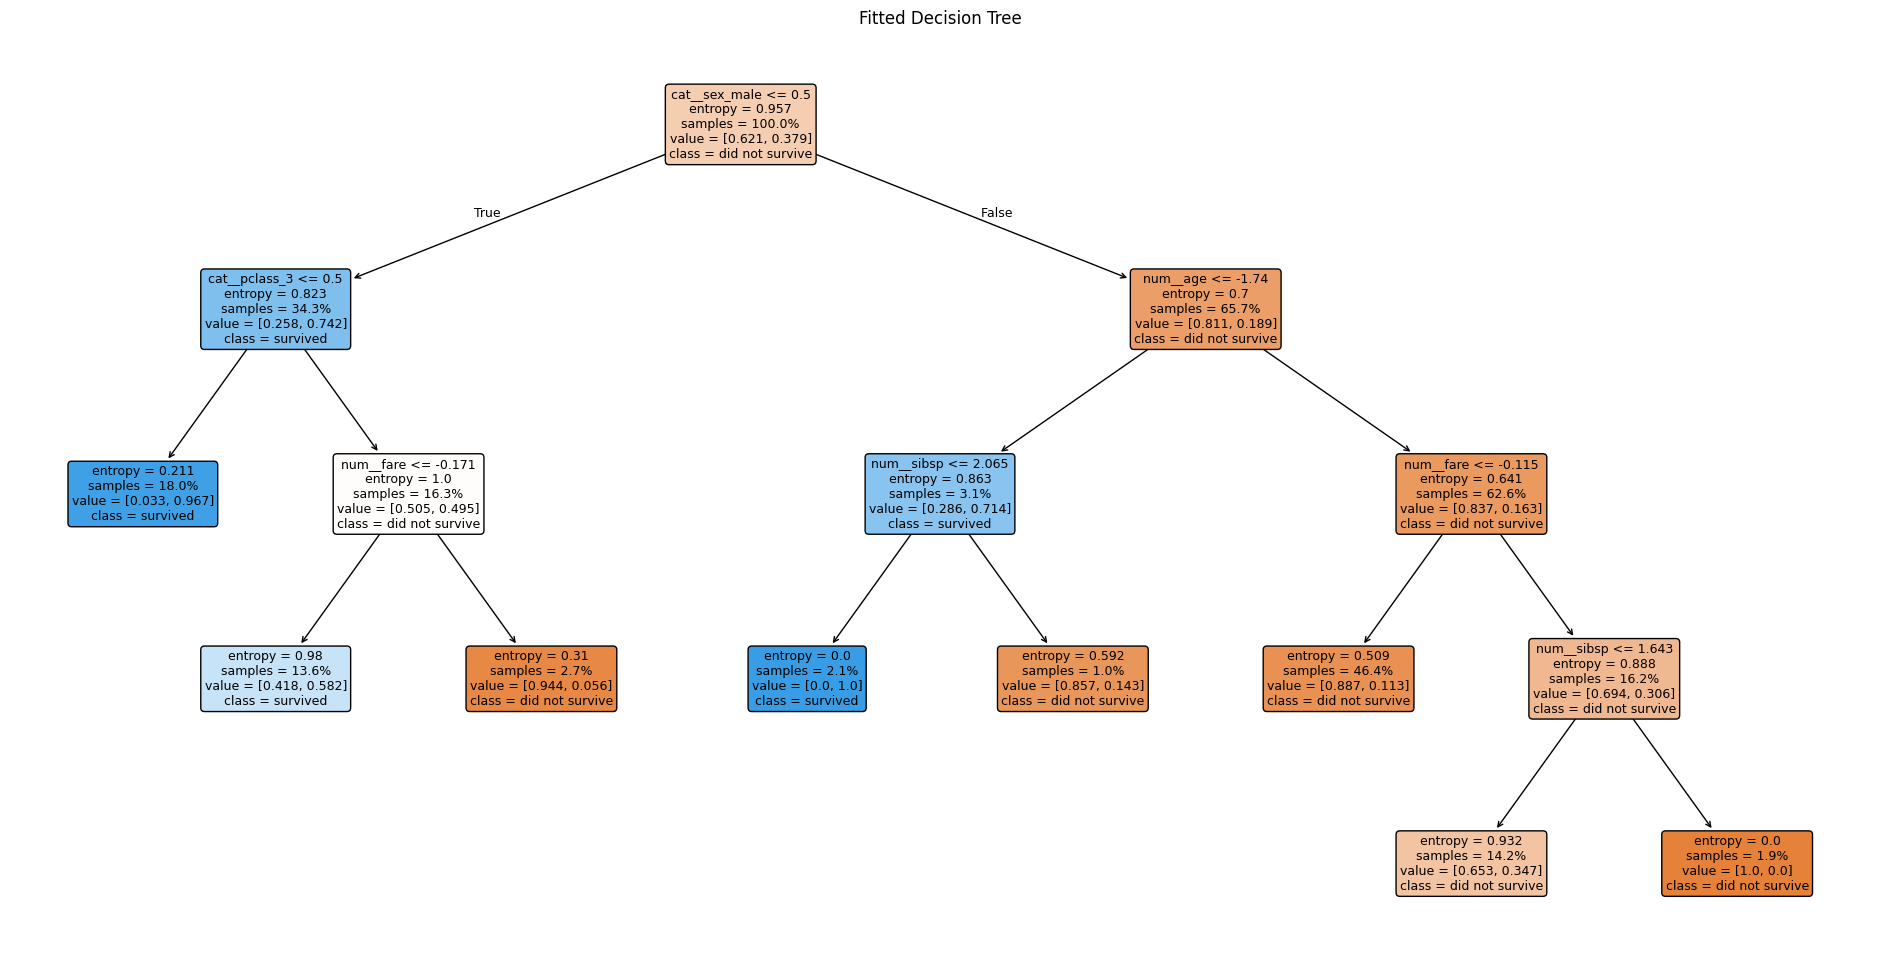

In [108]:
# To visualize the fitted tree, we extract the preprocessing step and the tree model.
#
# Because the categorical variables were one-hot encoded, the final design matrix
# has more columns than the original data. We therefore ask the preprocessor for
# the transformed feature names.
dt_preprocessor = best_dt.named_steps["preprocessor"]
dt_model = best_dt.named_steps["model"]

feature_names = dt_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
feature_names[:10]

# Plot the tree.
#
# Note: if the tree is large, the figure can become busy.
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["did not survive", "survived"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=9,
)
plt.title("Fitted Decision Tree")
plt.show()


## 14. Variable Importance in RF

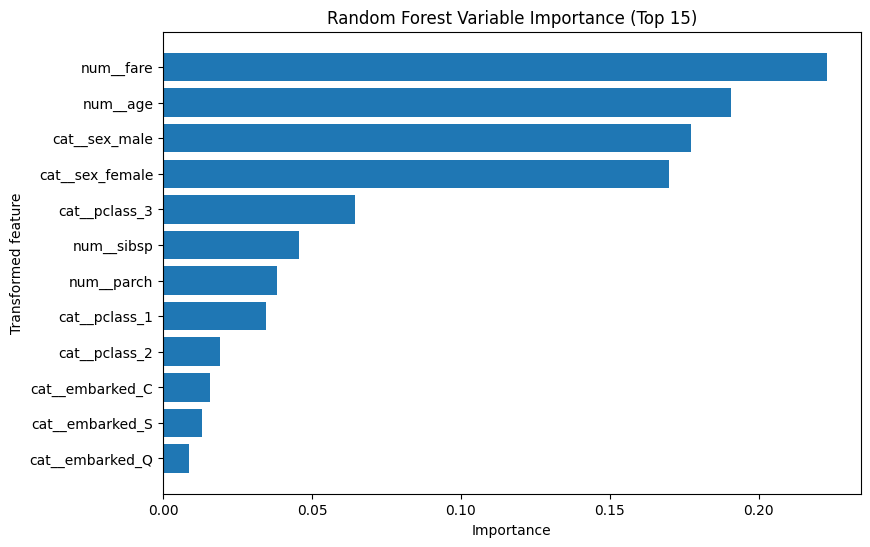

In [109]:
# Random forests provide feature_importances_ based on impurity reduction.
# We pair those importance scores with the transformed feature names.
rf_preprocessor = best_rf.named_steps["preprocessor"]
rf_model = best_rf.named_steps["model"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
rf_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

importance_df.head(15)


# Plot the top variable importances.
#
# Since one-hot encoding can create many transformed columns,
# it is often clearest to plot only the top features.
top_n = 15
top_importance_df = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Transformed feature")
plt.title(f"Random Forest Variable Importance (Top {top_n})")
plt.show()

## 15. Compute test-set scores

In [110]:
# For ROC analysis, we want the predicted score for the positive class.
# In sklearn, predict_proba(X)[:, 1] gives the model's estimated probability
# of class 1 for each observation.
dt_scores = best_dt.predict_proba(X_test)[:, 1]
rf_scores = best_rf.predict_proba(X_test)[:, 1]

print("Decision Tree test AUC:", round(roc_auc_score(y_test, dt_scores), 4))
print("Random Forest test AUC:", round(roc_auc_score(y_test, rf_scores), 4))


Decision Tree test AUC: 0.8448
Random Forest test AUC: 0.8642


## 16. Helper function for a simple KDE

In [82]:
# The function below returns a smooth estimated density curve for values in [0, 1].
def kde_curve(values, grid, bandwidth=None):
    values = np.asarray(values, dtype=float)
    n = len(values)

    if n == 0:
        return np.zeros_like(grid)

    if bandwidth is None:
        # Silverman's rule of thumb, with a small floor
        std = np.std(values, ddof=1) if n > 1 else 0.1
        bandwidth = 1.06 * std * n ** (-1 / 5) if std > 0 else 0.05
        bandwidth = max(bandwidth, 0.03)

    diff = (grid[:, None] - values[None, :]) / bandwidth
    density = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bandwidth * np.sqrt(2 * np.pi))
    return density


## 17. Plot score distributions by class

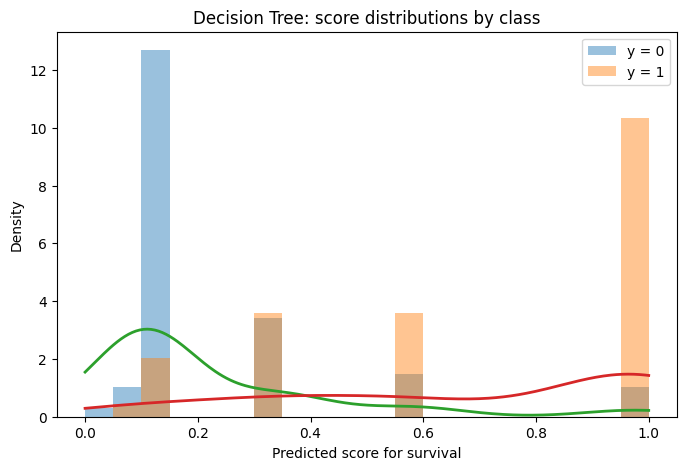

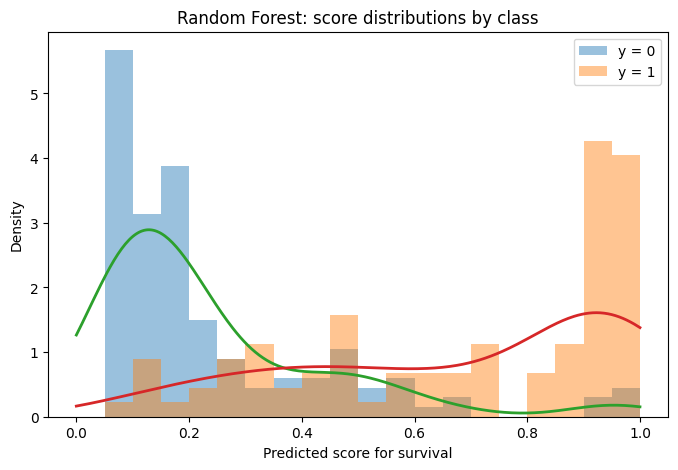

In [83]:
# This plot is useful for connecting machine learning scores to
# class-conditional distributions:
#
# - distribution of scores given y = 0
# - distribution of scores given y = 1
#
# The ROC curve later comes from sweeping a threshold across these scores.
def plot_score_distribution(y_true, scores, title):
    pos = scores[y_true == 1]
    neg = scores[y_true == 0]

    bins = np.linspace(0, 1, 21)
    grid = np.linspace(0, 1, 300)

    plt.figure(figsize=(8, 5))
    plt.hist(neg, bins=bins, density=True, alpha=0.45, label="y = 0")
    plt.hist(pos, bins=bins, density=True, alpha=0.45, label="y = 1")
    plt.plot(grid, kde_curve(neg, grid), linewidth=2)
    plt.plot(grid, kde_curve(pos, grid), linewidth=2)
    plt.xlabel("Predicted score for survival")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()

plot_score_distribution(y_test.values, dt_scores, "Decision Tree: score distributions by class")
plot_score_distribution(y_test.values, rf_scores, "Random Forest: score distributions by class")


## 18. Plot ROC curves

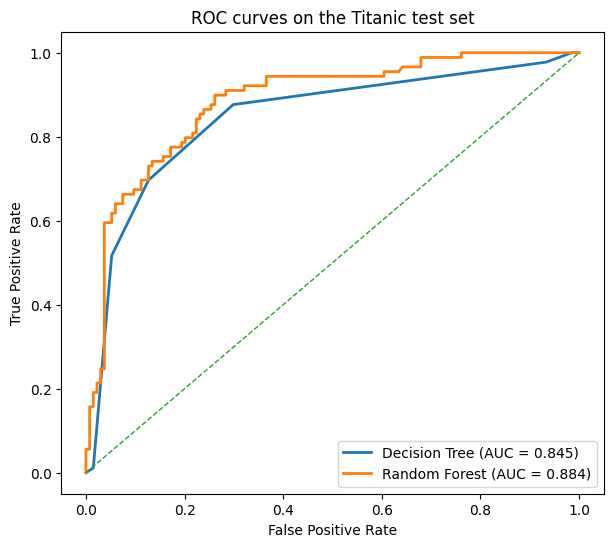

In [84]:
# The ROC curve is computed by sweeping a classification threshold over the scores.
# For each threshold, we compute:
# - FPR = false positive rate
# - TPR = true positive rate
#
# This plot lets us compare the two models over all possible thresholds.
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_scores)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_scores)

auc_dt = roc_auc_score(y_test, dt_scores)
auc_rf = roc_auc_score(y_test, rf_scores)

plt.figure(figsize=(7, 6))
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on the Titanic test set")
plt.legend(loc="lower right")
plt.show()



## 19. How to bring model selection into the pipeline


In [91]:
# ============================================================
# SINGLE PIPELINE WITH MODEL SELECTION
# ============================================================

# - preprocessing also accepts hyperparameters
# - the final model itself can be treated as a hyperparameter
# - cross-validation can choose BOTH:
#     (i) the model class (tree vs forest)
#     (ii) the hyperparameters within that class

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# Step 1: Define a pipeline with a placeholder model
# ------------------------------------------------------------
# The placeholder just needs to be a valid estimator.
# It will be replaced during GridSearchCV.
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))  # placeholder, will be overruled during CV
])

# ------------------------------------------------------------
# Step 2: Define a param grid that includes DIFFERENT MODELS
# ------------------------------------------------------------
# Each dictionary corresponds to a different hyperparameter family.
# GridSearchCV will try all combinations within each block.

model_hyperparams = [

    # -------------------------
    # Decision Tree block
    # -------------------------
    {
        "preprocessor__num__imputer__strategy":['most_frequent','median'],
        "model": [DecisionTreeClassifier(random_state=42)],
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [2, 5, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 10, 20],
        "model__ccp_alpha": [0.0, 0.001, 0.01],
    },

    # -------------------------
    # Random Forest block
    # -------------------------
    {
        "preprocessor__num__imputer__strategy":['most_frequent','median'],
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": [100, 200, 400],
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", "log2"],
    }
]

# ------------------------------------------------------------
# Step 3: Run cross-validated model selection
# ------------------------------------------------------------
# We use ROC AUC because we are working with score-based evaluation.
search = GridSearchCV(
    pipe,
    model_hyperparams,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=3
)

search.fit(X_train, y_train)

# ------------------------------------------------------------
# Step 4: Inspect results
# ------------------------------------------------------------
print("Best CV AUC:", round(search.best_score_, 4))
print("Best hyperparams:")
print(search.best_params_)

# Extract best model
best_model = search.best_estimator_

Fitting 5 folds for each of 1512 candidates, totalling 7560 fits
[CV 2/5] END model=DecisionTreeClassifier(random_state=42), model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=5, preprocessor__num__imputer__strategy=most_frequent;, score=0.894 total time=   0.0s
[CV 1/5] END model=DecisionTreeClassifier(random_state=42), model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=1, model__min_samples_split=10, preprocessor__num__imputer__strategy=most_frequent;, score=0.767 total time=   0.0s
[CV 2/5] END model=DecisionTreeClassifier(random_state=42), model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_leaf=10, model__min_samples_split=10, preprocessor__num__imputer__strategy=median;, score=0.894 total time=   0.0s
[CV 1/5] END model=DecisionTreeClassifier(random_state=42), model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=2, model__min_samples_lea

/Users/ramirezamayas/aml26/venv_aml26/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



[CV 3/5] END model=RandomForestClassifier(random_state=42), model__criterion=gini, model__max_depth=8, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=400, preprocessor__num__imputer__strategy=median;, score=0.797 total time=   0.2s
[CV 4/5] END model=RandomForestClassifier(random_state=42), model__criterion=gini, model__max_depth=8, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=400, preprocessor__num__imputer__strategy=median;, score=0.858 total time=   0.3s
[CV 5/5] END model=RandomForestClassifier(random_state=42), model__criterion=gini, model__max_depth=8, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=400, preprocessor__num__imputer__strategy=median;, score=0.876 total time=   0.3s
[CV 1/5] END model=RandomForestClassifier(random_state=42), model__criterion=gini, model__max_depth=8, model__max_features=sqrt, model__min_s

In [92]:
joint_results = pd.DataFrame(search.cv_results_)
joint_results["model_class"] = joint_results["param_model"].apply(lambda m: type(m).__name__)

print("Best overall joint-search candidate:")
display(
    joint_results[["model_class", "mean_test_score", "rank_test_score", "params"]]
    .sort_values("rank_test_score")
    .head(1)
)

print("Best Decision Tree candidate within joint search:")
display(
    joint_results[joint_results["model_class"] == "DecisionTreeClassifier"][
        ["model_class", "mean_test_score", "params"]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(1)
)

print("Best Random Forest candidate within joint search:")
display(
    joint_results[joint_results["model_class"] == "RandomForestClassifier"][
        ["model_class", "mean_test_score", "params"]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(1)
)

Best overall joint-search candidate:


,model_class,mean_test_score,rank_test_score,params
873,RandomForestClassifier,0.866195,1,{'model': RandomForestClassifier(random_state=...


Best Decision Tree candidate within joint search:


,model_class,mean_test_score,params
169,DecisionTreeClassifier,0.847974,{'model': DecisionTreeClassifier(random_state=...


Best Random Forest candidate within joint search:


,model_class,mean_test_score,params
927,RandomForestClassifier,0.866195,{'model': RandomForestClassifier(random_state=...


[CV 3/5] END model=RandomForestClassifier(random_state=42), model__criterion=entropy, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=most_frequent;, score=0.799 total time=   0.1s
[CV 2/5] END model=RandomForestClassifier(random_state=42), model__criterion=entropy, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=400, preprocessor__num__imputer__strategy=most_frequent;, score=0.905 total time=   0.2s
[CV 1/5] END model=RandomForestClassifier(random_state=42), model__criterion=entropy, model__max_depth=3, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100, preprocessor__num__imputer__strategy=median;, score=0.818 total time=   0.1s
[CV 3/5] END model=RandomForestClassifier(random_state=42), model__criterion=entropy, model__max_depth=3, model__max_fe